# Saliency — the whole pipeline, from OSM tile to event-study curve

Executable peer-review copy of the live instrument. Data is pulled from this GitHub repository (or a local `data/` checkout). Seeds are disclosed. Re-run all cells from the top.

Van Dijcke, D., Wright, A. L., & Polyak, M. (2023). Public response to government alerts saves lives during Russian invasion of Ukraine. *PNAS*, 120(18), e2220160120.

**We claim:** a GWT cycle with a hard ignition bar produces a delayed then decaying displacement pulse; habituation and calendar foils are separable; 25 interface checks pass on a city that is not Kyiv; agents start on WorldPop mass, not survey PSUs; appraisal is the probability of the union of WVS cues, not an arithmetic sum.

**We do not claim:** recovery of the original PNAS coefficients; a Simile 0.16 threshold; wartime 2022 density; fitted confidence intervals; that $\tau = 230$ is independently measured; that the Dirichlet prior means are estimated from a shelter-seeking item (WVS has none).

Expected numbers (same seeds as the instrument): architecture **25/25**, pre-trend **identically 0**. Peaks move because mapping weights, idle bars and $\tau$ are sampled per agent.


## Map of the argument

A professor reading this should be able to walk the data from disk to a displacement pulse without opening any other file. The instrument is the same population, running; this notebook is the argument. Nothing here is a second model.

| # | Stage | What happens |
|---|-------|----------------|
| 01 | Ingest | OSM footprints, SRTM, WorldPop 2020, WVS Wave 7 Kyiv, alert times, reconstructed Van Dijcke |
| 02 | Lattice | 250 m grid, occupied cells, shelter graph, metro, WorldPop mass |
| 03 | Population | Joint resample of WVS respondents; WorldPop homes; lag, speed, Dirichlet/Beta/log-normal processor draws |
| 04 | Sense | Siren on/off; $s_0\exp(-n/\tau)$; routine sets the attention bar |
| 05 | Ignite | If saliency ≥ attention the coalition occupies the workspace; otherwise the rest of the cycle never hears it |
| 06 | Appraise | WVS constructs are probabilities. Threat is their union (noisy-OR). Stay_Safe $= P(\mathrm{hear})\cdot P(\mathrm{floor}\cup\mathrm{threat})$ |
| 07 | Plan | Means-end: shelter here / walk to nearest shelter / evacuate |
| 08 | Motor | P1: nothing moves before $t=0$. Then own log-normal lag, then Bohannon speed |
| 09 | Window | Mean metres, $t=-10\ldots+30$. That vector is the simulated event-study curve |
| 10 | Judge | 25 architecture checks. Identifying design. Shape vs reconstructed Van Dijcke. Honest miss on levels |


## 0 · Setup

The engine lives in `saliency/` (a line-for-line port of `src/sim/*.ts`). If this notebook is opened on its own, the first cell installs the package from GitHub. Data lives in `data/` in this repo, or is fetched from GitHub raw URLs.


In [1]:
import sys
import subprocess
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPO = "https://github.com/testing-crsscl/saliency-kyiv.git"

def ensure_engine() -> str:
    here = Path.cwd()
    for candidate in (here, here.parent, here / "review", here.parent / "review"):
        if (candidate / "saliency" / "__init__.py").exists():
            sys.path.insert(0, str(candidate))
            return f"local {candidate}"
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", f"git+{REPO}"])
    return "pip " + REPO

print("engine", ensure_engine())

from saliency.data import load_bundle, source_label, GITHUB_URL, RAW_BASE
from saliency.core import (
    APPRAISAL_CUE_LABELS, APPRAISAL_PRIOR, DEFAULT_PARAMS, MINUTES, PERIODS, ACTIONS,
    acoustic_saliency, appraise_threat, build_env, defiance_strength, draw_processor,
    make_population, mulberry32, stay_safe_saliency, synthetic_city, threat_cues,
    union_probability,
)
from saliency.analysis import (
    PIPELINE, acoustic_table, appraisal_breakdown, confidence_note, folds_note,
    placement_audit, processor_audit, run_architecture_tests, run_dual_regions,
    run_first_alert, run_period, typical_kyivan_appraisal, worked_example,
    wvs_distributions,
)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
})

print("GitHub", GITHUB_URL)
print("data  ", source_label())
print("raw   ", RAW_BASE)
bundle = load_bundle()
env = build_env(bundle["grid"])
print("grid  ", bundle["grid"]["n"], "×", bundle["grid"]["n"], "at", bundle["grid"]["cellM"], "m")
print("cells ", bundle["grid"]["occupied"], "occupied,", bundle["grid"]["buildings"], "OSM footprints")
print("people", round(bundle["grid"].get("popOnOccupied") or 0), "WorldPop 2020 constrained")
print("WVS   n =", bundle["wvs"]["nKyiv"], "Kyiv city (UA-30)")
print("alerts", bundle["sirens"]["nVanDijckeWindow"], "in", bundle["sirens"]["window"])
print("params (population means)", DEFAULT_PARAMS)
print("rng   mulberry32 — JS unsigned >>>, signed |0, Math.imul")
print("pipeline stages", len(PIPELINE))


engine local /workspace/review
GitHub https://github.com/testing-crsscl/saliency-kyiv
data   local checkout (/workspace/review/data)
raw    https://raw.githubusercontent.com/testing-crsscl/saliency-kyiv/main/data
grid   174 × 174 at 250.0 m
cells  7146 occupied, 114005 OSM footprints
people 3338494 WorldPop 2020 constrained
WVS   n = 123 Kyiv city (UA-30)
alerts 407 in 2022-03-15/2022-09-30
params (population means) {'idleThreshold': 0.3, 'acousticBase': 0.93, 'habituationTau': 230, 'calendarTauDays': 201}
rng   mulberry32 — JS unsigned >>>, signed |0, Math.imul
pipeline stages 10


## 1 · Question

After an air-raid siren, who in a city actually moves, how far, and why does the pulse shrink as alerts accumulate? Van Dijcke et al. document a sharp sheltering response that attenuates over 2022. Two mechanisms fit that fact equally well from the outside:

1. **Habituation.** A region’s response depends on its own exposure history. Acoustic saliency of the siren decays as $s_0\cdot\exp(-n/\tau)$.
2. **Calendar.** Two regions on the same date behave the same, regardless of how many alerts each has heard. Their time constant is 201 days in the source study.

Only the first supports a conclusion about how alerts should be issued. The notebook therefore has to show the two models can be told apart, and that the architecture cannot move before $t = 0$.


## 2 · Ingest — what is on disk, and what it is allowed to mean

Every input is classified.

- *Measured* — a file we hold.
- *Reconstructed* — digitised from a published figure.
- *Transferred* — a named study on a different population.
- *Calibrated* — chosen so a reconstructed ratio is recoverable.
- *Assumed* — a named prior we draw from, not a coefficient estimated from the survey.

The next cell prints the ledger and a raw sample of each file so the pipeline starts from input, not from a summary statistic.


In [2]:
g, w, s, vd = bundle["grid"], bundle["wvs"], bundle["sirens"], bundle["vd"]
ledger = [
    ("Alert times / durations / local hour", s["source"][:110], "measured"),
    ("Terrain (SRTM terrarium z=12)", f"{g.get('elevMin')}–{g.get('elevMax')} m. Typical RMSE ±10 m. Not lidar.", "measured"),
    ("WorldPop 2020 constrained 100 m", g.get("popSource") or "WorldPop 2020 constrained 100 m, snapped onto OSM buildings", "measured"),
    ("OSM footprints / heights", f"{g['buildings']:,} footprints. {g['levelsKnown']:,} have building:levels. {g.get('heightKnown') or 0} have a height tag.", "measured / imputed"),
    ("WVS Wave 7 Ukraine, Kyiv city UA-30", w.get("source", "WVS Wave 7 v5.1")[:110], "measured (joint resample)"),
    ("Bohannon 1997 gait", "age/sex walking speed + residual σ 0.18 m/s", "transferred"),
    ("PADM / Purser decision lag", "log-normal, median 3.2 min, floor 1", "transferred"),
    ("Time-use circadian mix", "asleep / committed / idle by hour and weekday", "transferred"),
    ("Habituation τ median 230", "calibrated to reconstructed Mar–Apr / Jul–Sep peak ratio", "calibrated"),
    ("Appraisal Dirichlet prior", "structural WVS weights; no shelter-seeking item exists", "assumed"),
    ("CATALINA idle bar mean 0.30", "not Simile 0.16; individuals draw Beta(12,28) around 0.30", "named"),
    ("Dehaene acoustic mean 0.93", "individuals draw Beta(28, 2.1) around 0.93", "named"),
    ("Van Dijcke event-study curves", vd["source"][:110], "reconstructed"),
    ("Shelter capacity", "Metro cells plus top 12% of floor area. OSM has no bomb-shelter layer.", "assumed"),
]
print(f"{'role':<22} {'what'}")
print("-" * 110)
for what, src, role in ledger:
    print(f"{role:<22} {what}")
    print(f"{'':22} {src}")

print()
print("window", s["window"], "·", s["nVanDijckeWindow"], "merged Kyiv-city alerts (raw", s["nRaw"], "merged", s["nMerged"], ")")
print("median duration", round(s["medianDurMin"], 1), "min")
alert0 = s["windowAlerts"][0]
print("first window alert", alert0["t"], "dur", alert0["dur"], "min · prior n =", alert0["n"], "hour", alert0.get("hour"), "wd", alert0.get("wd"))

print()
print("— one WVS Kyiv respondent (pool[0]) —")
row = w["pool"][0]
for k in ("age", "sex", "sc", "df", "au", "ca", "cg", "se", "ns", "fi", "em", "w"):
    print(f"  {k:4} {row.get(k)}")

print()
print("— one occupied grid cell (cells[0]) —")
cell = g["cells"][0]
for k in sorted(cell.keys()):
    print(f"  {k:10} {cell[k]}")

print()
print("VD overall length", len(vd["overall"]), "periods", list(vd.get("byPeriod", {}).keys()))
print("files on disk/GitHub: kyiv-grid.json.gz, wvs-kyiv.json, sirens-kyiv.json, vandijcke-reconstructed.json")


role                   what
--------------------------------------------------------------------------------------------------------------
measured               Alert times / durations / local hour
                       Vadimkin / eTryvoga official_data_en.csv. Kyiv City, oblast level. Overlaps merged.
measured               Terrain (SRTM terrarium z=12)
                       82–209 m. Typical RMSE ±10 m. Not lidar.
measured               WorldPop 2020 constrained 100 m
                       WorldPop and DLR (2022). Gridded population estimates for Ukraine using UN COD-PS estimates 2020, version 2.0. Constrained 100 m, CC BY. https://data.worldpop.org/repo/wopr/UKR/v2/constrained/
measured / imputed     OSM footprints / heights
                       114,005 footprints. 38,003 have building:levels. 763 have a height tag.
measured (joint resample) WVS Wave 7 Ukraine, Kyiv city UA-30
                       WVS Wave 7 Ukraine 2020, v5.1 (Haerpfer et al.). Fielded before the invasion. 

## 3 · Lattice — the city is a measured grid, not a slider

Kyiv is a $173\times 173$ lattice at 250 m. Occupied cells carry OSM buildings. Elevation is SRTM. Population is WorldPop 2020 constrained 100 m, snapped onto buildings. Pre-war. Not a 2022 wartime map — Kyiv emptied in March 2022.

Agents path at cell resolution. Placement follows WorldPop mass, not WVS PSU coordinates (architecture T21).


occupied 7146 mass total 3338494
elev 82 – 209 m SRTM
shelters 1009 metro 195
pop on occupied 3338494 snapped from off-mask 402213
footprints 114005 levels known 38003


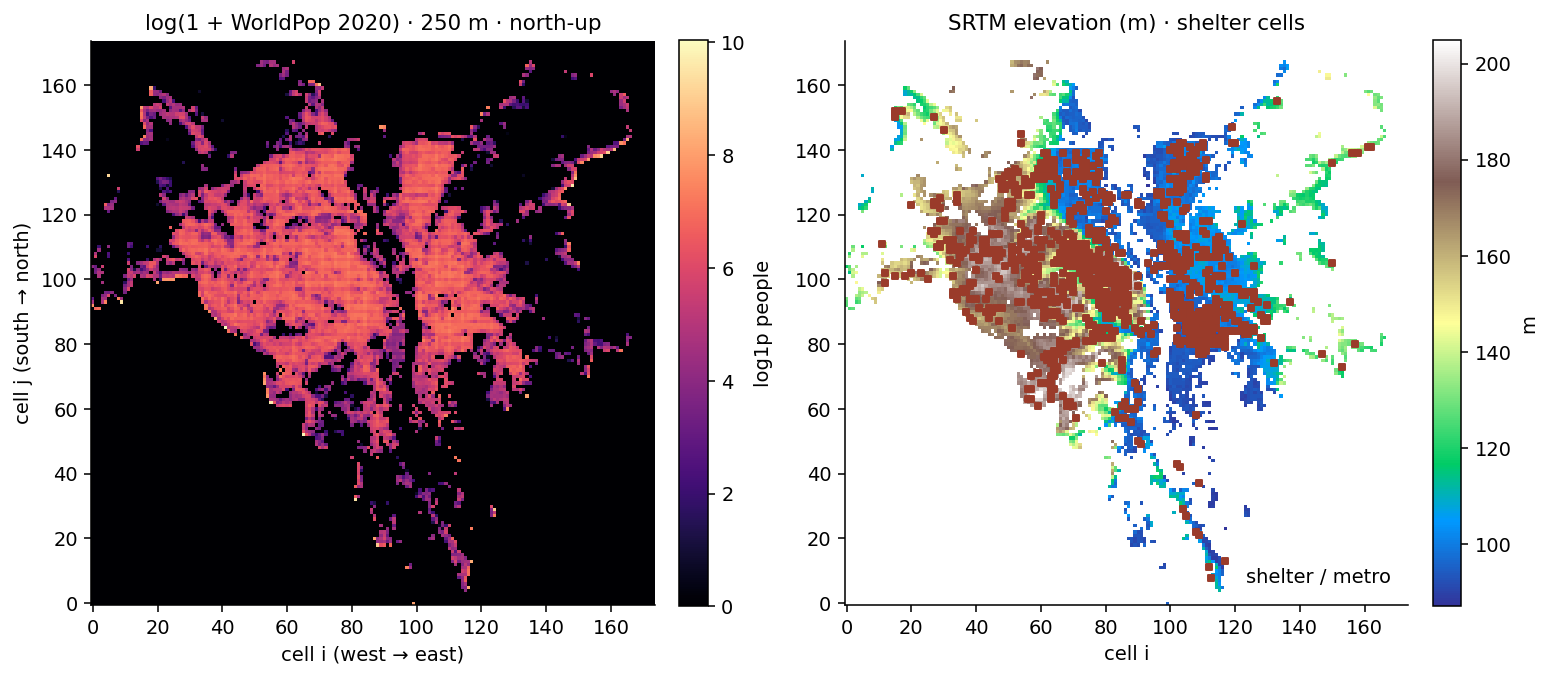

In [3]:
n = env["n"]
mass = np.zeros((n, n))
elev = np.full((n, n), np.nan)
shelter = np.zeros((n, n))
metro = np.zeros((n, n))
for cell, m in zip(env["cells"], env["mass"]):
    mass[cell["j"], cell["i"]] = m
    elev[cell["j"], cell["i"]] = cell.get("e") if cell.get("e") is not None else np.nan
    if cell.get("shelter"):
        shelter[cell["j"], cell["i"]] = 1
    if cell.get("metro"):
        metro[cell["j"], cell["i"]] = 1

fig, axes = plt.subplots(1, 2, figsize=(11.2, 5.2))
im0 = axes[0].imshow(np.log1p(mass), origin="lower", cmap="magma", interpolation="nearest")
axes[0].set_title("log(1 + WorldPop 2020) · 250 m · north-up")
axes[0].set_xlabel("cell i (west → east)")
axes[0].set_ylabel("cell j (south → north)")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="log1p people")
im1 = axes[1].imshow(elev, origin="lower", cmap="terrain", interpolation="nearest")
yy, xx = np.where(shelter > 0)
axes[1].scatter(xx, yy, s=8, c="#9a3b2a", marker="s", label="shelter / metro")
axes[1].set_title("SRTM elevation (m) · shelter cells")
axes[1].set_xlabel("cell i")
axes[1].legend(frameon=False, loc="lower right")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="m")
fig.tight_layout()
plt.show()

print("occupied", len(env["cells"]), "mass total", round(env["massTotal"]))
print("elev", g.get("elevMin"), "–", g.get("elevMax"), "m SRTM")
print("shelters", g["shelterCells"], "metro", g["metroCells"])
print("pop on occupied", round(g.get("popOnOccupied") or 0), "snapped from off-mask", round(g.get("popSnapped") or 0))
print("footprints", g["buildings"], "levels known", g["levelsKnown"])


400 agents landed on 384 of 7,146 occupied cells.
densest 10% of cells hold 30.7% of WorldPop mass and received 30.2% of agents.


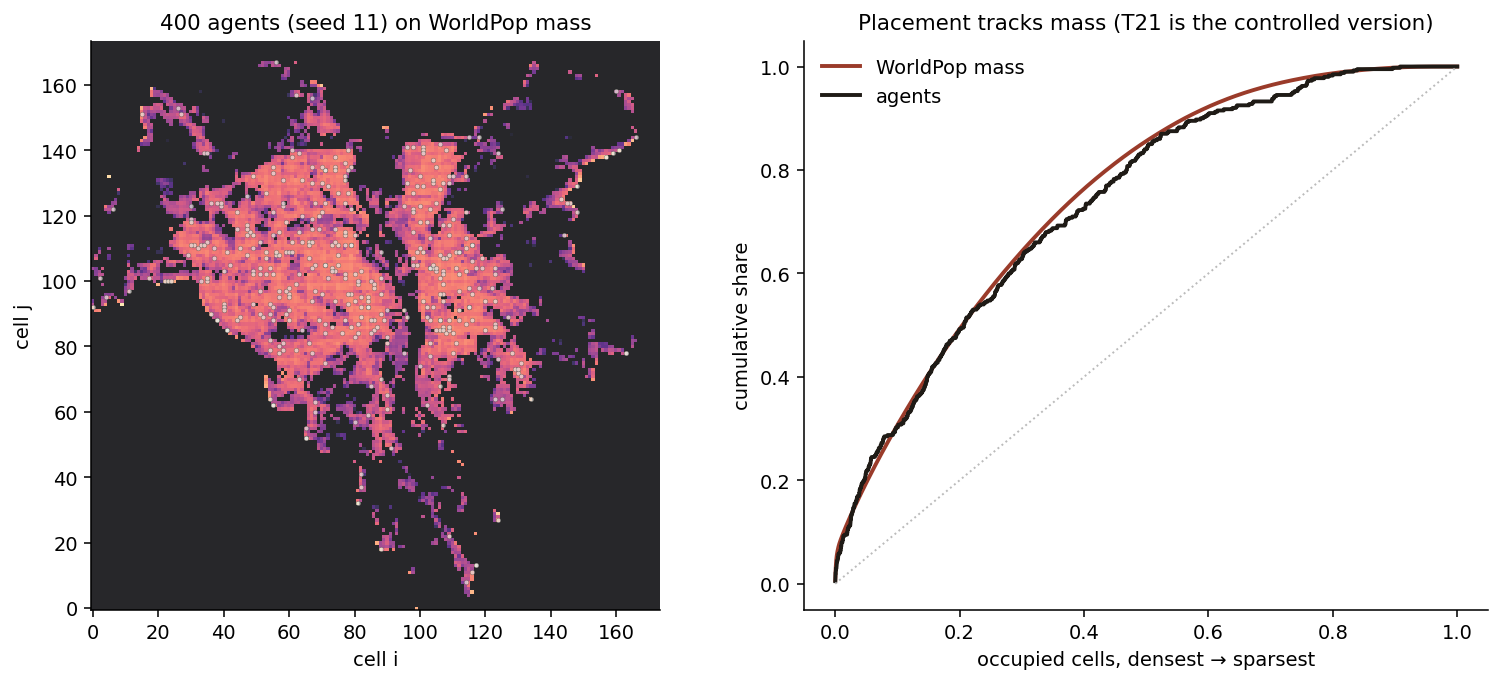

In [4]:
place = placement_audit(env, bundle["wvs"]["pool"], 400, 11)
print(f"{place['n']} agents landed on {place['unique']} of {place['occupied']:,} occupied cells.")
print(f"densest 10% of cells hold {place['popTopShare']*100:.1f}% of WorldPop mass "
      f"and received {place['agentsTopShare']*100:.1f}% of agents.")

fig, axes = plt.subplots(1, 2, figsize=(11.2, 5.0))
axes[0].imshow(np.log1p(mass), origin="lower", cmap="magma", interpolation="nearest", alpha=0.85)
xs = [a["i"] for a in place["pop"]]
ys = [a["j"] for a in place["pop"]]
axes[0].scatter(xs, ys, s=6, c="#e8e6e1", edgecolors="#1f1b16", linewidths=0.2, alpha=0.7)
axes[0].set_title("400 agents (seed 11) on WorldPop mass")
axes[0].set_xlabel("cell i")
axes[0].set_ylabel("cell j")

order = np.argsort(env["mass"])[::-1]
cum_mass = np.cumsum(np.array(env["mass"])[order]) / env["massTotal"]
counts = np.array(place["counts"])
cum_ag = np.cumsum(counts[order]) / place["n"]
frac = np.linspace(0, 1, len(order), endpoint=False) + 1 / len(order)
axes[1].plot(frac, cum_mass, color="#9a3b2a", lw=2, label="WorldPop mass")
axes[1].plot(frac, cum_ag, color="#1f1b16", lw=2, label="agents")
axes[1].plot([0, 1], [0, 1], color="#bbb", lw=1, ls=":")
axes[1].set_xlabel("occupied cells, densest → sparsest")
axes[1].set_ylabel("cumulative share")
axes[1].set_title("Placement tracks mass (T21 is the controlled version)")
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()


## 4 · Population — traits from WVS, homes from WorldPop, processors drawn

WVS Wave 7 Ukraine 2020, v5.1, fielded before the invasion. Kyiv city = `N_REGION_ISO` UA-30, $n=123$. Agents are drawn with survey weights from the Kyiv pool — a **joint**, not independent marginal PDFs. Location is discarded: those coordinates are PSU clusters, about two dozen points for the whole city.

```
seedAgent(id)
  belief      ← weighted draw from WVS Kyiv pool      // the joint, not a product of PDFs
  (i,j)       ← pickOccupiedWeighted(WorldPop mass)   // not belief.lat/lon
  routine     ← asleep / committed / idle at (hour, weekday, employed)
  lag         ← log-normal, median 3.2 min, floor 1     // PADM / Purser
  speed       ← Bohannon age/sex gait + σ 0.18 m/s
  sipBias     ← autonomy + age boost + noise
  γ_appraise  ← Dirichlet(κ=12 · structural prior)
  γ_defy      ← Dirichlet(κ=10 · [0.55, 0.20, 0.15])
  α_stay      ← Beta(8, 12)     mean 0.40
  idle bar    ← Beta(12, 28)    mean 0.30
  s₀          ← Beta(28, 2.1)   mean 0.93
  τ           ← log-normal, median 230, σ_ln 0.22
  thresholds  ← idle = own bar; committed 0.50→0.75; asleep 0.80→0.90
```

WVS has no shelter-seeking item — the Dirichlet means are a structural prior, not an estimate. The response of the population is the distribution of those probabilities, not a single linear index.


scepticism Kyiv 0.608 national 0.559
defiance  Kyiv 0.321 confArmy 0.575 security 0.6
typical threat (prior-mean γ) 0.494 Stay_Safe(0) 0.648 Stay_Safe(406) 0.111 P(defy) 0.328
female share 0.588 employed 0.664 n pool 119


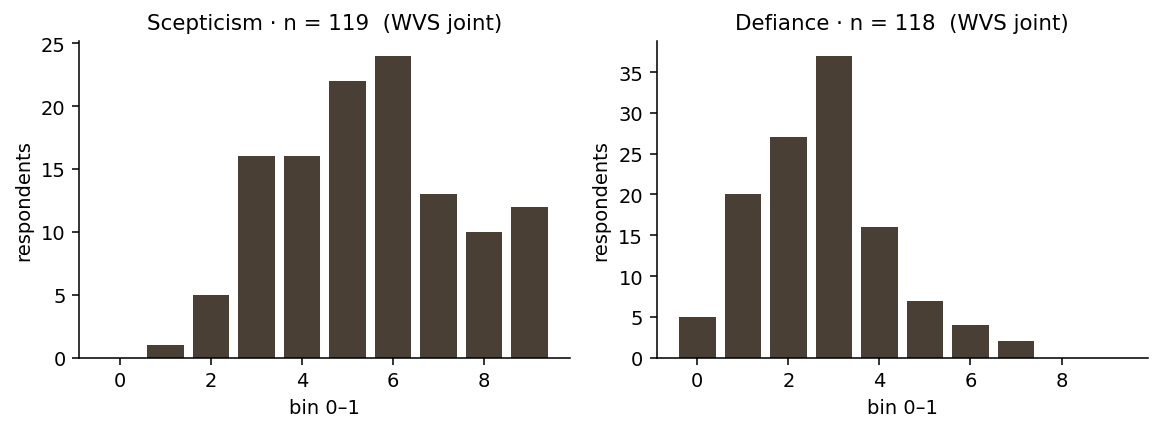

In [5]:
wvs = wvs_distributions(bundle["wvs"]["pool"])
kyiv = typical_kyivan_appraisal(bundle["wvs"])
print("scepticism Kyiv", round(bundle["wvs"]["scepticismKyiv"], 3),
      "national", round(bundle["wvs"]["scepticismNational"], 3))
print("defiance  Kyiv", round(bundle["wvs"]["defianceKyiv"], 3),
      "confArmy", round(bundle["wvs"].get("confArmyKyiv") or 0, 3),
      "security", round(bundle["wvs"].get("securityKyiv") or 0, 3))
print("typical threat (prior-mean γ)", round(kyiv["threat"], 3),
      "Stay_Safe(0)", round(kyiv["stay0"], 3),
      "Stay_Safe(406)", round(kyiv["stay406"], 3),
      "P(defy)", round(kyiv["defianceGate"], 3))
print("female share", round(wvs["femaleShare"], 3), "employed", round(wvs["employedShare"], 3),
      "n pool", wvs["n"])

fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.2))
for ax, key, title in ((axes[0], "scepticism", "Scepticism"), (axes[1], "defiance", "Defiance")):
    ax.bar(range(10), wvs[key]["counts"], color="#4a3f35")
    ax.set_title(f"{title} · n = {wvs[key]['n']}  (WVS joint)")
    ax.set_xlabel("bin 0–1")
    ax.set_ylabel("respondents")
fig.tight_layout()
plt.show()


processor draws n=240  seed 19
mean P(threat) 0.835  P(Stay_Safe) 0.840  P(defy) 0.586
60% of this draw have Stay_Safe ≥ defy at n = 0
mean |union − linear| 0.35


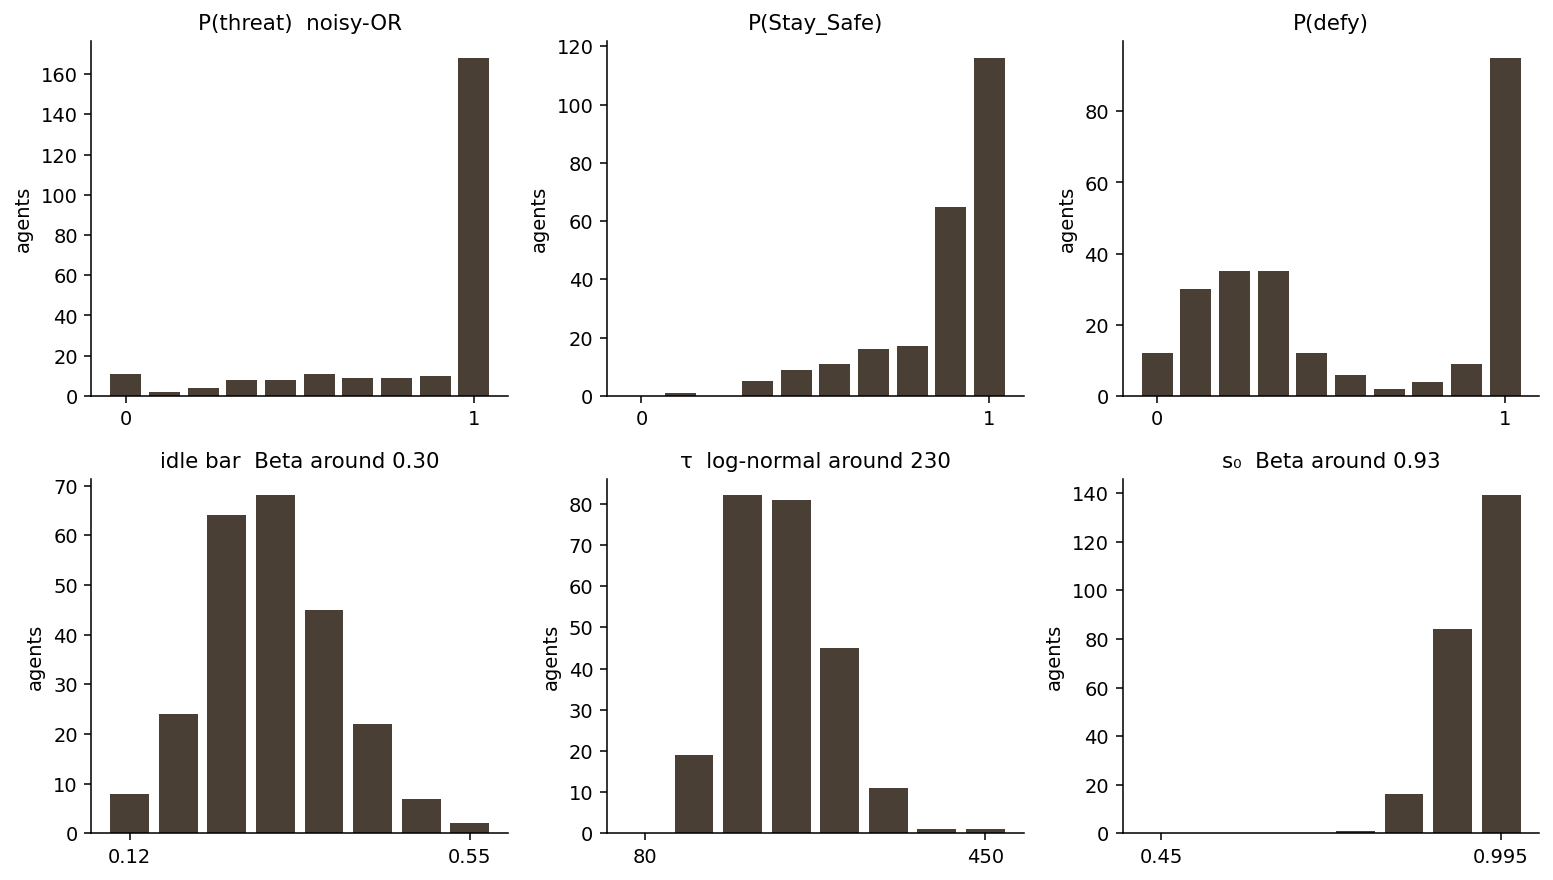

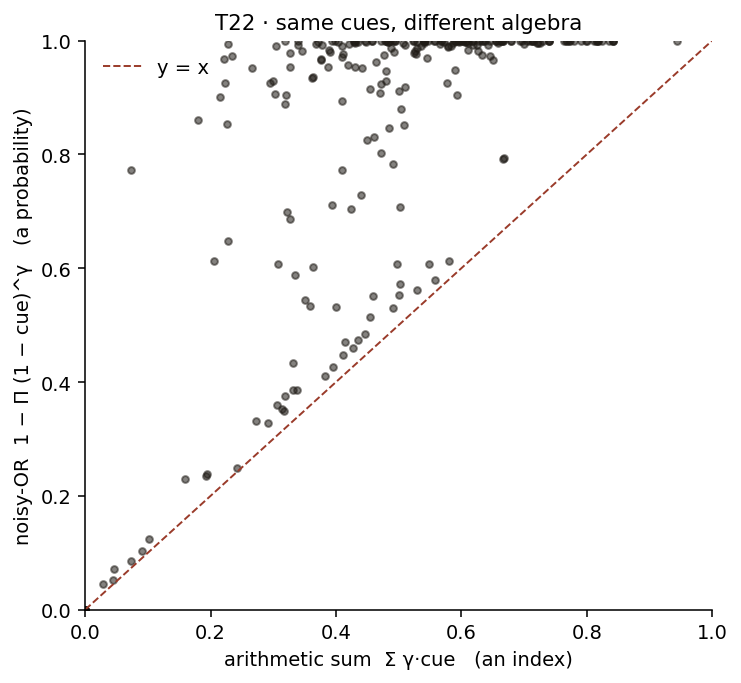

In [6]:
proc = processor_audit(bundle["wvs"]["pool"], 240, 19)
print(f"processor draws n={proc['n']}  seed 19")
print(f"mean P(threat) {proc['meanThreat']:.3f}  P(Stay_Safe) {proc['meanStay']:.3f}  P(defy) {proc['meanDefy']:.3f}")
print(f"{proc['comply']*100:.0f}% of this draw have Stay_Safe ≥ defy at n = 0")

fig, axes = plt.subplots(2, 3, figsize=(11.2, 6.4))
panels = [
    (axes[0, 0], proc["threat"]["counts"], "P(threat)  noisy-OR", 0, 1),
    (axes[0, 1], proc["stay"]["counts"], "P(Stay_Safe)", 0, 1),
    (axes[0, 2], proc["defy"]["counts"], "P(defy)", 0, 1),
    (axes[1, 0], proc["idle"]["counts"], "idle bar  Beta around 0.30", 0.12, 0.55),
    (axes[1, 1], proc["tau"]["counts"], "τ  log-normal around 230", 80, 450),
    (axes[1, 2], proc["s0"]["counts"], "s₀  Beta around 0.93", 0.45, 0.995),
]
for ax, counts, title, lo, hi in panels:
    ax.bar(range(len(counts)), counts, color="#4a3f35")
    ax.set_title(title)
    ax.set_xticks([0, len(counts) - 1], [f"{lo:g}", f"{hi:g}"])
    ax.set_ylabel("agents")
fig.tight_layout()
plt.show()

# union ≠ sum, same cues
pop = proc["pop"]
union = [appraise_threat(a) for a in pop]
linear = [sum(w * x for w, x in zip(a["appraisalW"], threat_cues(a))) for a in pop]
fig, ax = plt.subplots(figsize=(5.4, 5.0))
ax.scatter(linear, union, s=12, c="#1f1b16", alpha=0.55)
ax.plot([0, 1], [0, 1], color="#9a3b2a", lw=1, ls="--", label="y = x")
ax.set_xlabel("arithmetic sum  Σ γ·cue   (an index)")
ax.set_ylabel("noisy-OR  1 − Π (1 − cue)^γ   (a probability)")
ax.set_title("T22 · same cues, different algebra")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()
print("mean |union − linear|", round(float(np.mean(np.abs(np.array(union) - np.array(linear)))), 3))


routines at hour 14 weekday 2: {'asleep': 14, 'committed': 179, 'idle': 207}
walk 47–111 m/min  mean 81.9
lag  1–12 min          mean 3.9


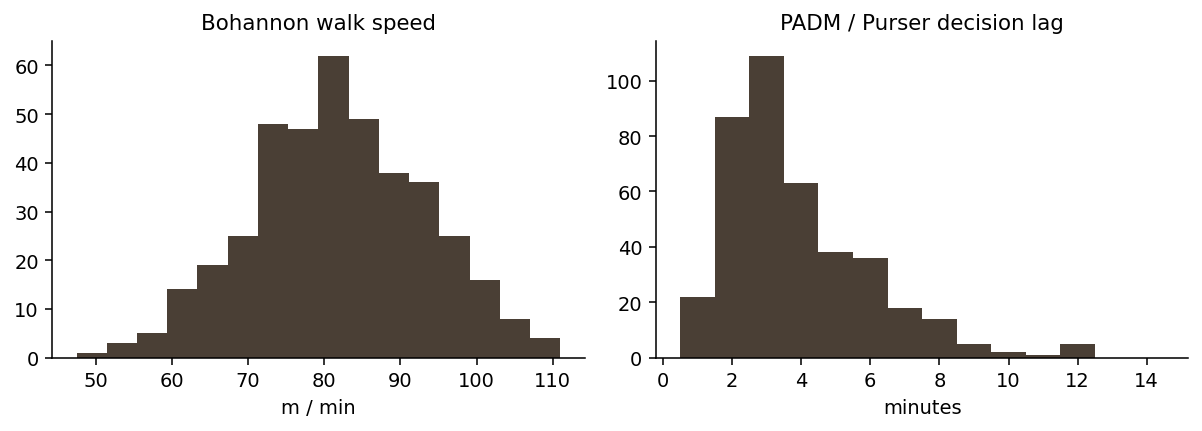

In [7]:
# motor / circadian draws from a Kyiv-placed population
rng = mulberry32(17)
kyiv_pop = make_population(400, env, bundle["wvs"]["pool"], DEFAULT_PARAMS, rng, 0, 14, 2)
speeds = [a["walkSpeedMpm"] for a in kyiv_pop]
lags = [a["decisionLagMin"] for a in kyiv_pop]
routines = {}
for a in kyiv_pop:
    routines[a["routine"]] = routines.get(a["routine"], 0) + 1
print("routines at hour 14 weekday 2:", {k: routines[k] for k in sorted(routines)})
print(f"walk {min(speeds):.0f}–{max(speeds):.0f} m/min  mean {np.mean(speeds):.1f}")
print(f"lag  {min(lags)}–{max(lags)} min          mean {np.mean(lags):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.2))
axes[0].hist(speeds, bins=16, color="#4a3f35")
axes[0].set_title("Bohannon walk speed")
axes[0].set_xlabel("m / min")
axes[1].hist(lags, bins=range(1, 16), color="#4a3f35", align="left")
axes[1].set_title("PADM / Purser decision lag")
axes[1].set_xlabel("minutes")
fig.tight_layout()
plt.show()


## 5 · Sense — the siren is a number that decays

$$s(n) = s_0\,\exp(-n/\tau)$$

$s_0 \sim \mathrm{Beta}(28, 2.1)$ (mean 0.93). $\tau$ is log-normal around 230. Idle bar $\sim \mathrm{Beta}(12, 28)$ (mean 0.30). Committed 0.75 and asleep 0.90 stay CATALINA identities. After ~360 alerts the *mean* idle population is silent; the left tail of the idle-bar distribution still ignites.

Median $\tau$ is calibrated so the reconstructed Mar–Apr / Jul–Sep peak ratio is recoverable from exposure. It is not independently measured.


     n   acoustic  P(idle ignites)  mean idle  committed   asleep
     0      0.930           100.0%       True       True     True
    40      0.782           100.0%       True       True    False
   100      0.602           100.0%       True      False    False
   175      0.435            95.2%       True      False    False
   220      0.357            82.8%       True      False    False
   230      0.342            74.0%       True      False    False
   360      0.194             7.0%      False      False    False
   406      0.159             0.5%      False      False    False


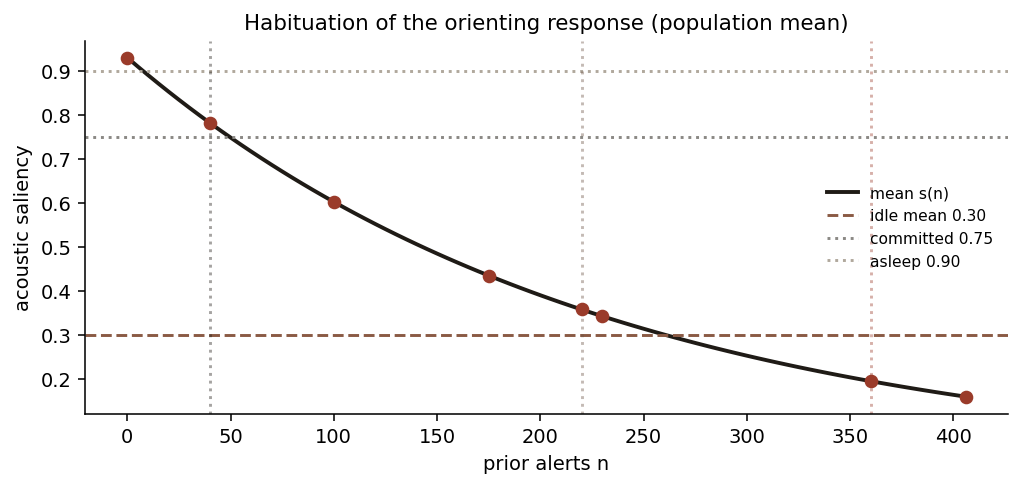

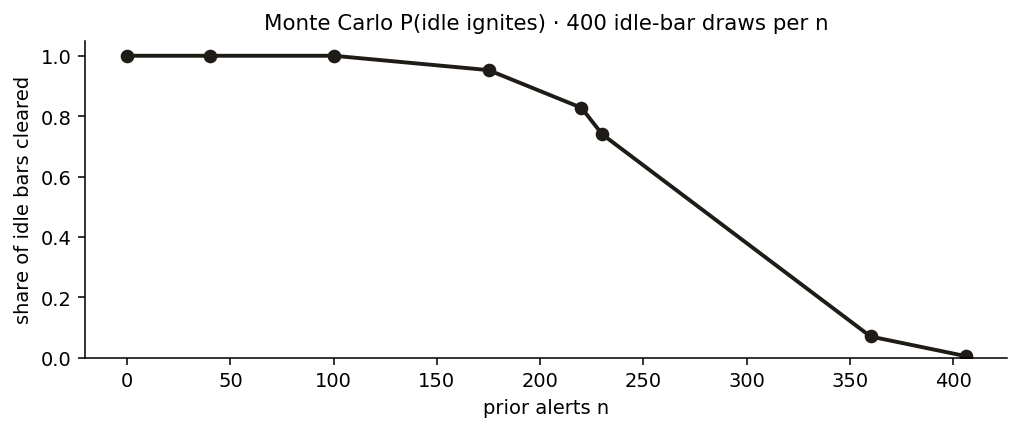

In [8]:
rows = acoustic_table()
print(f"{'n':>6} {'acoustic':>10} {'P(idle ignites)':>16} {'mean idle':>10} {'committed':>10} {'asleep':>8}")
for r in rows:
    print(f"{r['n']:6d} {r['acoustic']:10.3f} {r['idleShare']*100:15.1f}% "
          f"{str(r['ignitesIdle']):>10} {str(r['ignitesCommitted']):>10} {str(r['ignitesAsleep']):>8}")

xs = list(range(0, 410, 5))
ys = [acoustic_saliency(n) for n in xs]
fig, ax = plt.subplots(figsize=(7.4, 3.6))
ax.plot(xs, ys, color="#1f1b16", lw=2, label="mean s(n)")
ax.axhline(0.30, color="#8a5a44", ls="--", label="idle mean 0.30")
ax.axhline(0.75, color="#8a8884", ls=":", label="committed 0.75")
ax.axhline(0.90, color="#b0a89c", ls=":", label="asleep 0.90")
ax.axvline(40, color="#1f1b16", ls=":", alpha=0.4)
ax.axvline(220, color="#6b5344", ls=":", alpha=0.4)
ax.axvline(360, color="#9a3b2a", ls=":", alpha=0.4)
ax.scatter([r["n"] for r in rows], [r["acoustic"] for r in rows], c="#9a3b2a", zorder=3)
ax.set_xlabel("prior alerts n")
ax.set_ylabel("acoustic saliency")
ax.set_title("Habituation of the orienting response (population mean)")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.4, 3.2))
ax.plot([r["n"] for r in rows], [r["idleShare"] for r in rows], color="#1f1b16", lw=2, marker="o")
ax.set_xlabel("prior alerts n")
ax.set_ylabel("share of idle bars cleared")
ax.set_title("Monte Carlo P(idle ignites) · 400 idle-bar draws per n")
ax.set_ylim(0, 1.05)
fig.tight_layout()
plt.show()


## 6 · Workspace cycle — twelve named functions

Unconscious processors run in parallel. A coalition that clears the attention bar ignites and is broadcast. Sub-threshold content is **absent**, not deprioritised. That is the GWT claim (Baars; Dehaene & Changeux), specialised here as CATALINA’s MAPE cycle. The named functions below are the ones the engine actually calls, in this order, every agent-minute.

WVS constructs are already probabilities. Threat is the probability of their **union** (noisy-OR), not a weighted arithmetic sum:

$$P(\text{threat}) = 1 - \prod_i (1 - \text{cue}_i)^{\gamma_i}, \quad \gamma \sim \mathrm{Dirichlet}(\kappa \cdot \mu)$$

$$P(\text{Stay\_Safe}) = P(\text{hear}) \cdot \bigl(1 - (1-\alpha)(1-P(\text{threat}))\bigr)$$

$$P(\text{defy}) = 1 - \prod_j (1 - d_j)^{\delta_j}$$

Stay_Safe forms iff $P(\text{Stay\_Safe}) \ge P(\text{defy})$ (MAP of two probabilities).

P1: the motor gate is closed for every $t < 0$. The lag conjunct of `canAct` is already a log-normal draw. The other two conjuncts are architecture and physics.

```
acoustic(n)      = s₀ · exp(−n / τ)          s₀ ~ Beta, τ ~ log-normal
cues             = (1−sc, ca, se, cg, 1−ns, fi)   each already a probability
P(threat)        = 1 − ∏_i (1 − cue_i)^{γ_i}     γ ~ Dirichlet(κ·prior)
P(Stay_Safe)     = acoustic · [1 − (1−α)(1−P(threat))]
idle bar         ~ Beta(12, 28)                    mean 0.30
focused bar      = sal + (1−sal)/2     ≥ 0.50      CATALINA identity, not sampled
P(defy)          = 1 − ∏_j (1 − d_j)^{δ_j}        δ ~ Dirichlet
Stay_Safe forms  iff  P(Stay_Safe) ≥ P(defy)
canAct           = minute ≥ 0  ∧  minute ≥ own lag  ∧  siren on
```


In [9]:
layers = [
    ("L1 Perception", "perceptionProcessing", "Boolean: is the siren on this minute."),
    ("L2 Selection", "informationSelection", "Attach this agent's habituated acoustic saliency."),
    ("L3 Inhibition", "stimulusInhibition", "If saliency < attention bar, the stimulus is absent. Not deprioritised — gone."),
    ("L4 Workspace", "gwMaintenance", "Broadcast the winner, or empty the workspace."),
    ("L5 Deletion", "desireDeletion + intentionDeletion", "Drop contents below the current bar."),
    ("L6 Appraisal", "appraiseThreat", "Union of WVS probabilities with this agent's Dirichlet γ."),
    ("L7 Stay_Safe", "staySafeSaliency", "P(hear) · P(floor ∪ threat)."),
    ("L8 Defiance", "switchingToStimulus", "MAP: P(defy) vs P(Stay_Safe). Hearing is not complying."),
    ("L9 Means-end", "meansEndReasoner", "shelter_in_place / move / evacuate from distance and sipBias."),
    ("L10 Focus", "focusAgent / unfocusAgent", "CATALINA attention = sal + (1−sal)/2."),
    ("L11 Motor gate", "canAct (P1)", "Nothing moves before t = 0, before own lag, or after the siren ends."),
    ("L12 Execution", "planExecution", "18 m once for SIP. Walk = Bohannon m/min."),
]
for name, fn, what in layers:
    print(f"{name:22} {fn:36} {what}")
print()
print("typical Kyivan (prior-mean γ, not a draw)")
print(f"  P(threat)     {kyiv['threat']:.3f}")
print(f"  Stay_Safe(0)  {kyiv['stay0']:.3f}")
print(f"  Stay_Safe(406){kyiv['stay406']:.3f}")
print(f"  P(defy)       {kyiv['defianceGate']:.3f}")
print("focused-bar identity: sal + (1−sal)/2 ≥ 0.50 for every sal in [0,1)")


L1 Perception          perceptionProcessing                 Boolean: is the siren on this minute.
L2 Selection           informationSelection                 Attach this agent's habituated acoustic saliency.
L3 Inhibition          stimulusInhibition                   If saliency < attention bar, the stimulus is absent. Not deprioritised — gone.
L4 Workspace           gwMaintenance                        Broadcast the winner, or empty the workspace.
L5 Deletion            desireDeletion + intentionDeletion   Drop contents below the current bar.
L6 Appraisal           appraiseThreat                       Union of WVS probabilities with this agent's Dirichlet γ.
L7 Stay_Safe           staySafeSaliency                     P(hear) · P(floor ∪ threat).
L8 Defiance            switchingToStimulus                  MAP: P(defy) vs P(Stay_Safe). Hearing is not complying.
L9 Means-end           meansEndReasoner                     shelter_in_place / move / evacuate from distance and sipBias.
L10 F

## 7 · Worked minute — one Kyivan, three minutes, every layer

Drawn with seed 7 from the WVS Kyiv pool, placed on WorldPop mass, given the first window alert’s hour and exposure. This is not a fitted individual. It is a reproducible walk through the functions in §6.

Appraisal: each cue is a probability; $\gamma$ is this agent’s Dirichlet draw; $\mathrm{fire} = 1-(1-\mathrm{cue})^{\gamma}$.


agent  28 Female  routine asleep  cell (79,92)
sc 0.89  df 0.55  idleBar 0.23  s0 0.86  τ 260  α 0.40
acoustic 0.859  P(threat) 0.191  P(Stay_Safe) 0.445  P(defy) 0.952
attention 0.900  lag 3 min  speed 73 m/min

construct                            cue       γ  1-(1-cue)^γ
1 − scepticism                     0.113   0.351        0.041
confArmy                           0.333   0.152        0.060
security vs freedom                0.000   0.098        0.000
confGov                            0.000   0.301        0.000
1 − neighbourhood secure           0.667   0.097        0.101
willingness to fight               0.600   0.001        0.001
P(threat) = 1 − Π (1−cue)^γ                             0.191

=== t = -1  siren off  ·  P1 forbids motion  heard=False ignited=False defied=False continue           0.0 m ===
  L1     Perception                   [stop] siren OFF
  L2     Information selection        [stop] no stimulus (siren off)
  L3     Stimulus inhibition / ignition [stop] no sti

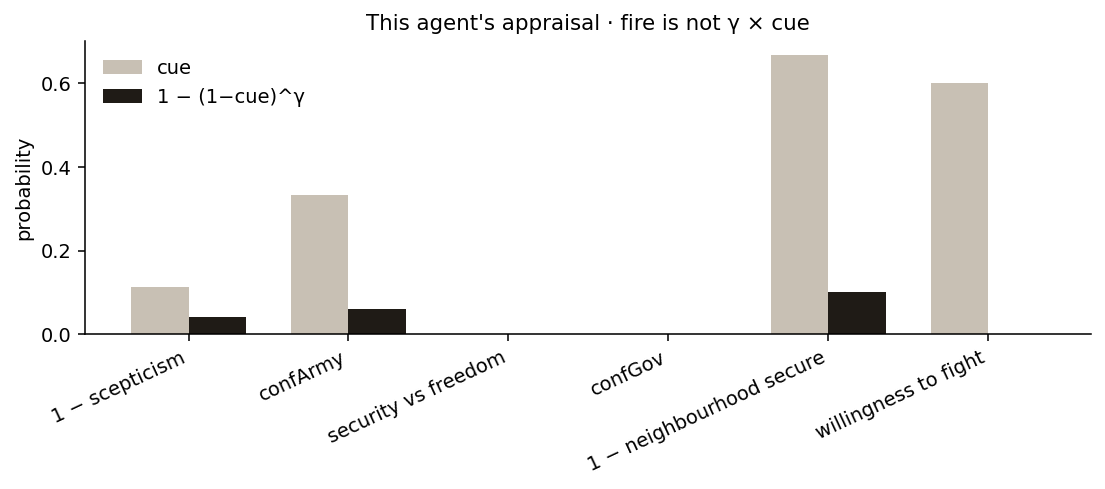

In [10]:
ex = worked_example(env, bundle["wvs"]["pool"], alert0["n"], alert0.get("hour", 16), alert0.get("wd", 2), 7)
a = ex["agent"]
parts = appraisal_breakdown(a)
print(f"agent  {a['age']:.0f} {a['sex']}  routine {a['routine']}  cell ({a['i']},{a['j']})")
print(f"sc {a['scepticism']:.2f}  df {a['defiance']:.2f}  idleBar {a['idleBar']:.2f}  "
      f"s0 {a['acousticBase']:.2f}  τ {a['habituationTau']:.0f}  α {a['stayMix']:.2f}")
print(f"acoustic {ex['acoustic']:.3f}  P(threat) {ex['threat']:.3f}  "
      f"P(Stay_Safe) {ex['stay']:.3f}  P(defy) {ex['defianceGate']:.3f}")
print(f"attention {ex['attention']:.3f}  lag {a['decisionLagMin']} min  speed {a['walkSpeedMpm']:.0f} m/min")
print()
print(f"{'construct':32} {'cue':>7} {'γ':>7} {'1-(1-cue)^γ':>12}")
for row in parts["parts"]:
    print(f"{row['label']:32} {row['value']:7.3f} {row['weight']:7.3f} {row['fire']:12.3f}")
print(f"{'P(threat) = 1 − Π (1−cue)^γ':32} {'':7} {'':7} {parts['threat']:12.3f}")

fig, ax = plt.subplots(figsize=(8.0, 3.6))
labels = [p["label"] for p in parts["parts"]]
x = np.arange(len(labels))
ax.bar(x - 0.18, [p["value"] for p in parts["parts"]], 0.36, color="#c8c0b4", label="cue")
ax.bar(x + 0.18, [p["fire"] for p in parts["parts"]], 0.36, color="#1f1b16", label="1 − (1−cue)^γ")
ax.set_xticks(x, labels, rotation=25, ha="right")
ax.set_ylabel("probability")
ax.set_title("This agent's appraisal · fire is not γ × cue")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

def show_trace(label, tr):
    print()
    print(f"=== {label}  heard={tr['heard']} ignited={tr['ignited']} defied={tr['defied']} "
          f"{tr['action']:18} {tr['metres']:.1f} m ===")
    for s in tr["steps"]:
        print(f"  {s['id']:6} {s['name']:28} [{s['gate']:4}] {s['value']}")

show_trace("t = -1  siren off  ·  P1 forbids motion", ex["pre"])
show_trace("t =  0  siren on, lag blocks the legs", ex["onset"])
show_trace(f"t = {ex['afterLag']['lag']}  siren on  ·  lag elapsed", ex["afterLag"])
print()
print("P1: metres at t<0 must be 0 —", ex["pre"]["metres"])


## 8 · Event window — from one agent-minute to a curve

`runEventWindow` clones the population, then for each minute $t \in [-10,+30]$ calls the cycle on every agent with `sirenOn = (t ≥ 0 and t before duration)`. Displacement at $t$ is the mean metres that minute. P1 is the claim that the mean is identically 0 for every $t$ before 0, at every point in parameter space — not on average, identically.

```
for t in −10 … +30:
  for each agent:
    workingCycle(agent, env, params, sirenOn, t)
    metres[t] += agent.metres
  displacement[t] = metres[t] / N
preTrendMax = max(displacement[t] for t < 0)     // must be 0
```

Shape MSE compares both after max-normalising; level MSE compares metres to metres. They answer different questions. Shape can look like a rhyme while levels fail by two orders of magnitude.

Seed 21, $N = 140$ — the same call the instrument makes.


sim peak 19.23 m at t = 6
VD  peak 1491.5 m
shape MSE 0.056 level MSE 486491.0
pre-trend max 0.0 (must be 0)
asleep 8 committed 56 idle 76
mean walk 81.1 m/min  mean lag 4.0 min
nAgents 140


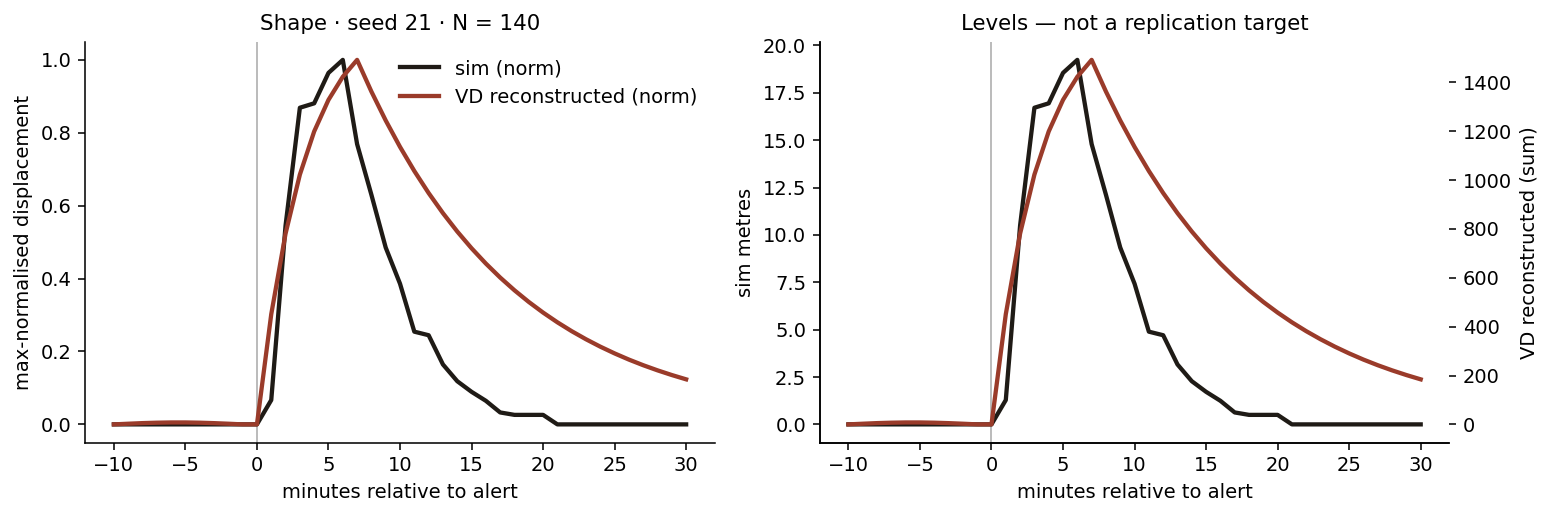

In [11]:
first = run_first_alert(env, bundle["wvs"]["pool"], alert0, bundle["vd"], 140, 21)
sim = first["result"]["displacement"]
vd_curve = bundle["vd"]["overall"]
print("sim peak", round(first["result"]["peakMetres"], 2), "m at t =", first["result"]["peakMinute"])
print("VD  peak", round(first["vdPeak"], 1), "m")
print("shape MSE", round(first["shapeMse"], 3), "level MSE", round(first["levelMse"], 0))
print("pre-trend max", first["result"]["preTrendMax"], "(must be 0)")
assert first["result"]["preTrendMax"] == 0
print("asleep", first["result"]["nAsleep"], "committed", first["result"]["nCommitted"], "idle", first["result"]["nIdle"])
print("mean walk", round(first["result"]["meanWalk"], 1), "m/min  mean lag", round(first["result"]["meanLag"], 1), "min")
print("nAgents", first["result"]["nAgents"])

smax = max(sim) or 1
vmax = max(vd_curve) or 1
fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.8))
axes[0].axvline(0, color="#bbb", lw=1)
axes[0].plot(MINUTES, [v / smax for v in sim], color="#1f1b16", lw=2.2, label="sim (norm)")
axes[0].plot(MINUTES, [v / vmax for v in vd_curve], color="#9a3b2a", lw=2.2, label="VD reconstructed (norm)")
axes[0].set_xlabel("minutes relative to alert")
axes[0].set_ylabel("max-normalised displacement")
axes[0].set_title("Shape · seed 21 · N = 140")
axes[0].legend(frameon=False)
axes[1].axvline(0, color="#bbb", lw=1)
axes[1].plot(MINUTES, sim, color="#1f1b16", lw=2.2, label="sim, mean m")
ax2 = axes[1].twinx()
ax2.plot(MINUTES, vd_curve, color="#9a3b2a", lw=2.2, label="VD reconstructed")
axes[1].set_xlabel("minutes relative to alert")
axes[1].set_ylabel("sim metres")
ax2.set_ylabel("VD reconstructed (sum)")
axes[1].set_title("Levels — not a replication target")
fig.tight_layout()
plt.show()


## 8b · What the population is doing — action mix and workspace


at t=0  {'continue': 0.4, 'shelter_in_place': 0.229, 'move': 0.321, 'evacuate': 0.05}
at peak {'continue': 0.421, 'shelter_in_place': 0.321, 'move': 0.221, 'evacuate': 0.036}
ignited at peak 0.486 defied 0.386


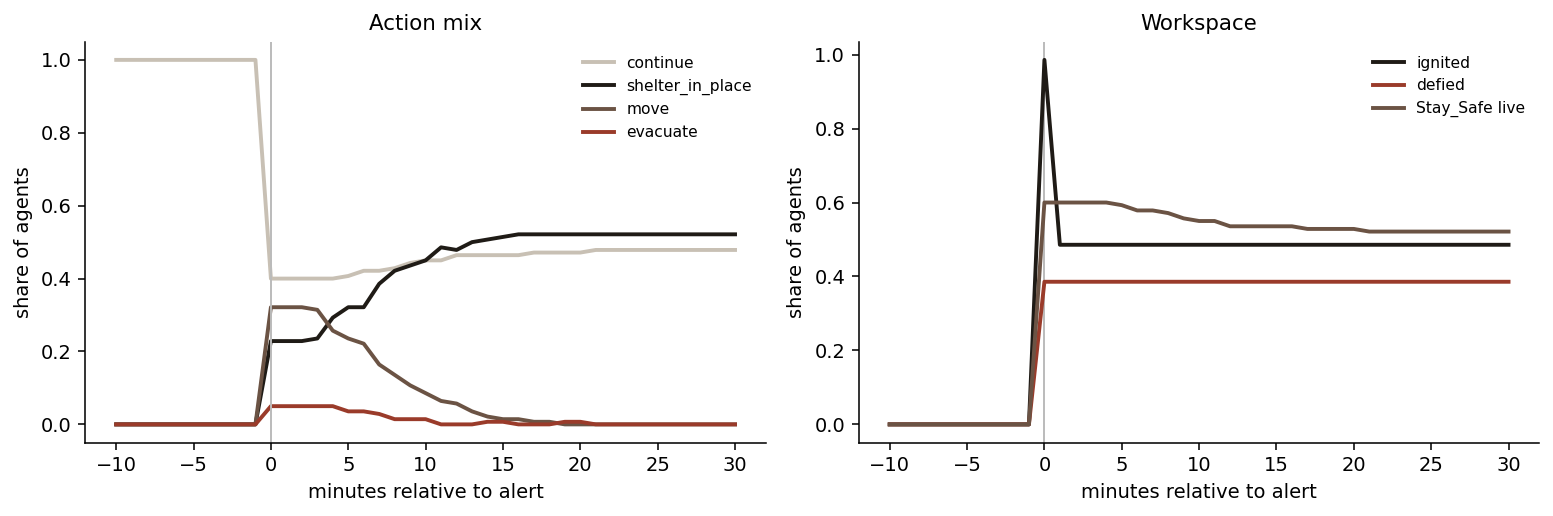

In [12]:
actions = first["result"]["actions"]
gw = first["result"]["gw"]
fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.8))
palette = {
    "continue": "#c8c0b4",
    "shelter_in_place": "#1f1b16",
    "move": "#6b5344",
    "evacuate": "#9a3b2a",
}
for key in ACTIONS:
    axes[0].plot(MINUTES, [row[key] for row in actions], color=palette[key], lw=2, label=key)
axes[0].axvline(0, color="#bbb", lw=1)
axes[0].set_xlabel("minutes relative to alert")
axes[0].set_ylabel("share of agents")
axes[0].set_title("Action mix")
axes[0].legend(frameon=False, fontsize=8)
axes[1].axvline(0, color="#bbb", lw=1)
axes[1].plot(MINUTES, [g["ignited"] for g in gw], color="#1f1b16", lw=2, label="ignited")
axes[1].plot(MINUTES, [g["defied"] for g in gw], color="#9a3b2a", lw=2, label="defied")
axes[1].plot(MINUTES, [g["staySafe"] for g in gw], color="#6b5344", lw=2, label="Stay_Safe live")
axes[1].set_xlabel("minutes relative to alert")
axes[1].set_ylabel("share of agents")
axes[1].set_title("Workspace")
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

t0 = first["result"]["minutes"].index(0)
peak_i = first["result"]["minutes"].index(first["result"]["peakMinute"])
print("at t=0 ", {k: round(actions[t0][k], 3) for k in ACTIONS})
print("at peak", {k: round(actions[peak_i][k], 3) for k in ACTIONS})
print("ignited at peak", round(gw[peak_i]["ignited"], 3), "defied", round(gw[peak_i]["defied"], 3))


## 9 · Identifying design — two regions, two foils

A decaying pulse over 2022 does not identify habituation. Calendar time produces the same qualitative fact. Split a synthetic city: A heard 40 alerts, B heard 160, same date.

- **Habituation foil** — acoustic saliency uses each region’s own $n$. A must out-move B.
- **Calendar foil** — same date-constant for both. A and B must match.

This is run on a city that is **not** Kyiv.


habituation A/B 40.9 17.2 ratio 2.37
calendar    A/B 22.1 16.8 ratio 1.31


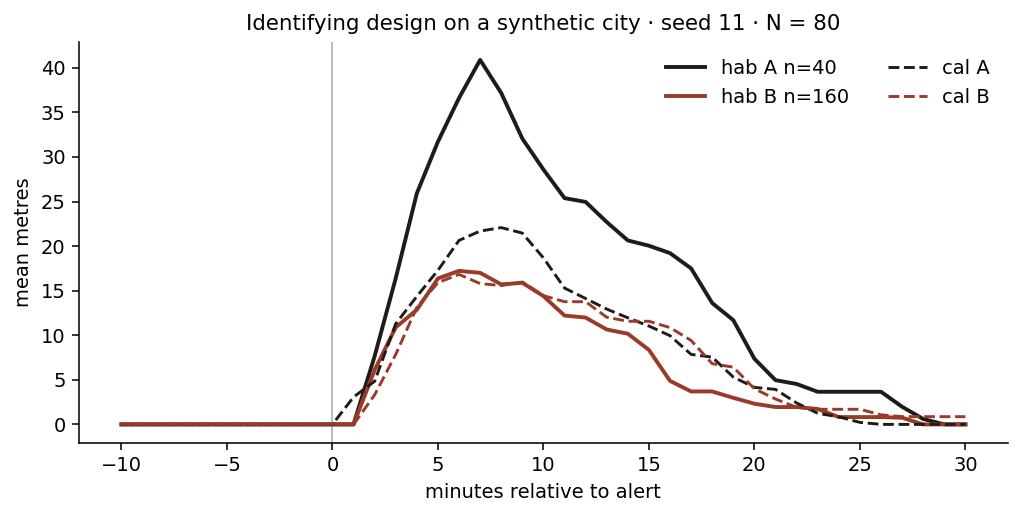

In [13]:
dual = run_dual_regions(build_env(synthetic_city(12)), bundle["wvs"]["pool"], 80, DEFAULT_PARAMS, 120, 40, 160, 11)
print("habituation A/B", round(dual["habituation"]["a"]["peakMetres"], 1),
      round(dual["habituation"]["b"]["peakMetres"], 1),
      "ratio", round(dual["habituation"]["ratio"], 2))
print("calendar    A/B", round(dual["calendar"]["a"]["peakMetres"], 1),
      round(dual["calendar"]["b"]["peakMetres"], 1),
      "ratio", round(dual["calendar"]["ratio"], 2))

fig, ax = plt.subplots(figsize=(7.4, 3.8))
ax.axvline(0, color="#bbb", lw=1)
ax.plot(MINUTES, dual["habituation"]["a"]["displacement"], color="#1f1b16", lw=2, label="hab A n=40")
ax.plot(MINUTES, dual["habituation"]["b"]["displacement"], color="#9a3b2a", lw=2, label="hab B n=160")
ax.plot(MINUTES, dual["calendar"]["a"]["displacement"], color="#1f1b16", lw=1.5, ls="--", label="cal A")
ax.plot(MINUTES, dual["calendar"]["b"]["displacement"], color="#9a3b2a", lw=1.5, ls="--", label="cal B")
ax.set_xlabel("minutes relative to alert")
ax.set_ylabel("mean metres")
ax.set_title("Identifying design on a synthetic city · seed 11 · N = 80")
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
plt.show()


## 10 · Architecture — twenty-five checks on a city that is not Kyiv

Interface tests run on a 12×12 synthetic city so they cannot be smuggled Kyiv-specific facts. P1 (no pre-trend) and P2 (focused attention floor 0.50) are the load-bearing claims. T21 is the WorldPop-versus-WVS-coordinates trap. T22–T25 are the claim that appraisal is a probability of a union, with sampled weights, not a shared linear index.

Must be **25/25**.


25/25 pass
PASS P1   No pre-trend possible                                   max displacement t<0 is 0.0000 m (must be 0 at every point in parameter space)
PASS P2   Focused attention threshold floor of 0.50               attention = sal + (1−sal)/2 ≥ 0.5 for every sal in [0,1). CATALINA arithmetic, not a choice of ours.
PASS T03  Attention formula                                       committed 0.50 → 0.75; asleep 0.80 → 0.90
PASS T04  Idle thresholds equal                                   Unfocused: saliency threshold = attention threshold = idle default
PASS T05  Sub-threshold stimulus never enters the workspace       A 0.40 siren against a 0.75 bar is invisible — not deprioritised, absent. GWT ignition failed.
PASS T06  No one hears the siren before t=0                       heard[t<0] ≡ 0
PASS T07  Nobody walks at t=0 (own lag ≥ 1)                       displacement at t=0 is 0.0. Lags are log-normal with a floor of 1 min.
PASS T08  Synthetic 12×12 city is occupied               

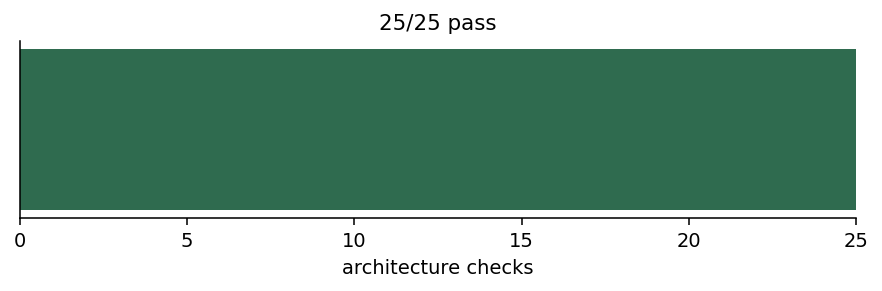

In [14]:
tests = run_architecture_tests()
n_ok = sum(1 for t in tests if t["ok"])
print(f"{n_ok}/{len(tests)} pass")
assert n_ok == 25, tests
for t in tests:
    mark = "PASS" if t["ok"] else "FAIL"
    print(f"{mark:4} {t['id']:4} {t['name']:55} {t['detail'][:100]}")

fig, ax = plt.subplots(figsize=(6.4, 2.2))
ax.barh([0], [n_ok], color="#2f6b4f")
ax.barh([0], [len(tests) - n_ok], left=[n_ok], color="#9a3b2a")
ax.set_xlim(0, len(tests))
ax.set_yticks([])
ax.set_xlabel("architecture checks")
ax.set_title(f"{n_ok}/{len(tests)} pass")
fig.tight_layout()
plt.show()


## 11 · Event study — three periods, judged against a reconstruction

Van Dijcke’s event-study files are not in hand. The comparison series is digitised from the published figure (distance sum, metres, window $[-10,+30]$). Shape can be compared. Levels cannot be claimed as a replication. $N = 120$ per period, seeds 31, 32, 33.


period         n  acoustic        sim       VD    shape
Mar–Apr       40     0.782     15.8 m     2100    0.056
May–Jun      220     0.357      6.9 m     1303    0.060
Jul–Sep      360     0.194     silent      733    0.210


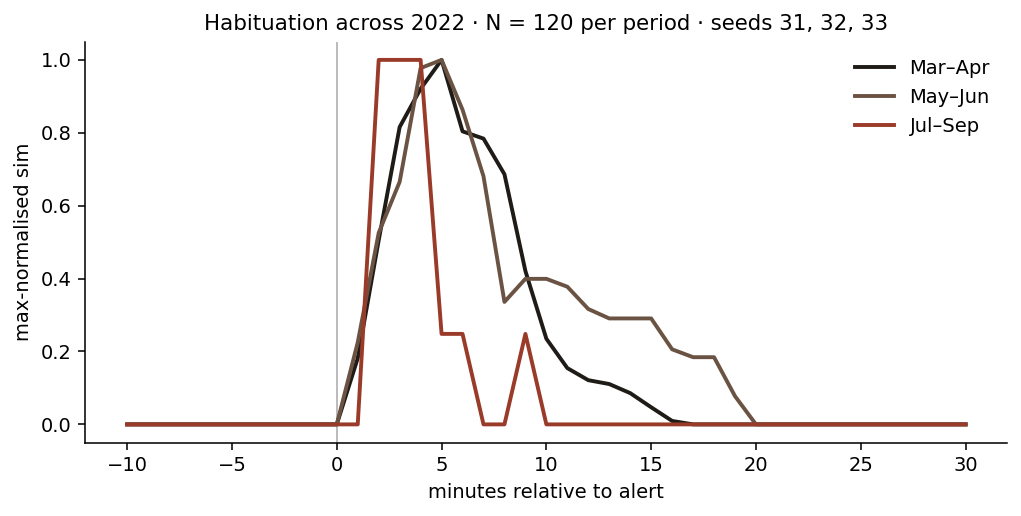

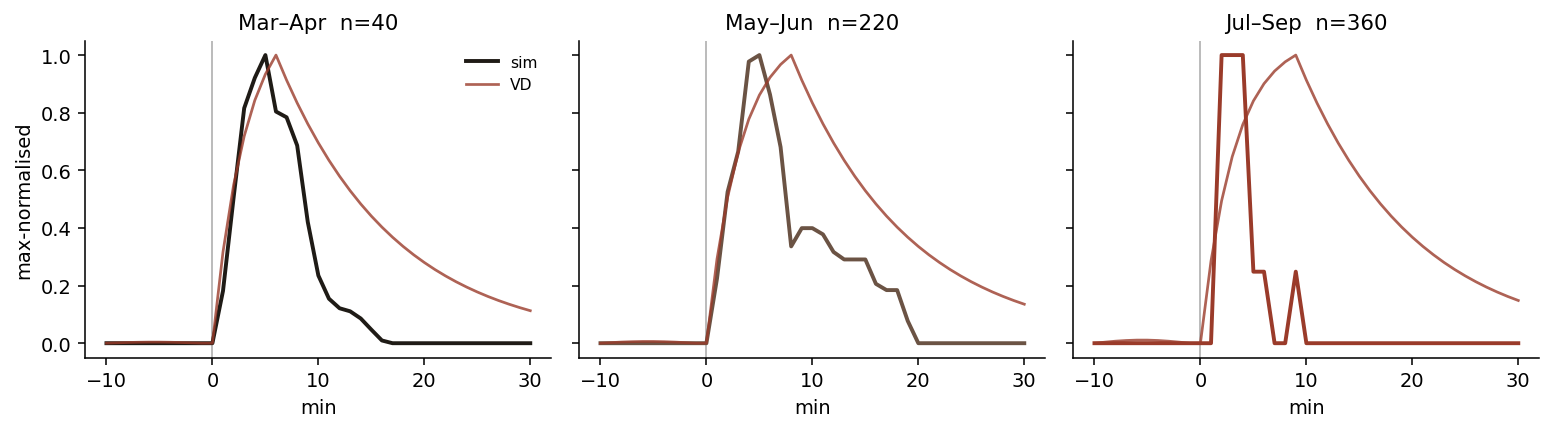

In [15]:
periods = [run_period(env, bundle["wvs"]["pool"], bundle["sirens"]["windowAlerts"], bundle["vd"], p, 120, 31 + i)
           for i, p in enumerate(PERIODS)]
print(f"{'period':10} {'n':>5} {'acoustic':>9} {'sim':>10} {'VD':>8} {'shape':>8}")
for r in periods:
    sims = "silent" if r["silent"] else f"{r['peakSim']:.1f} m"
    print(f"{r['label']:10} {r['exposure']:5d} {r['acoustic']:9.3f} {sims:>10} {r['peakVd']:8.0f} {r['shapeMse']:8.3f}")

fig, ax = plt.subplots(figsize=(7.4, 3.8))
ax.axvline(0, color="#bbb", lw=1)
colors = ["#1f1b16", "#6b5344", "#9a3b2a"]
for r, c in zip(periods, colors):
    m = max(r["displacement"]) or 1
    ax.plot(MINUTES, [v / m for v in r["displacement"]], color=c, lw=2, label=r["label"])
ax.set_xlabel("minutes relative to alert")
ax.set_ylabel("max-normalised sim")
ax.set_title("Habituation across 2022 · N = 120 per period · seeds 31, 32, 33")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.2), sharey=True)
for ax, r, c in zip(axes, periods, colors):
    sm = max(r["displacement"]) or 1
    vm = max(r["vd"]) or 1
    ax.axvline(0, color="#bbb", lw=1)
    ax.plot(MINUTES, [v / sm for v in r["displacement"]], color=c, lw=2, label="sim")
    ax.plot(MINUTES, [v / vm for v in r["vd"]], color="#9a3b2a", lw=1.4, alpha=0.8, label="VD")
    ax.set_title(f"{r['label']}  n={r['exposure']}")
    ax.set_xlabel("min")
axes[0].set_ylabel("max-normalised")
axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()


## 12 · How good is the model

Architecture is the claim most nearly earned. Identification holds in the model’s own world: habituation separates two regions on the same date; the calendar foil does not. Shape against a reconstruction is a visual rhyme in the first months. **Levels fail** — simulated peaks are tens of metres, reconstructed peaks are thousands — because the PNAS series is a distance *sum* over a phone panel, not mean metres per agent. Late-season silence against a still-positive reconstructed pulse is a real miss. Confidence is unfitted.

Evaluation folds are named regions, never random: West 1, West 2, South, East 1, East 2.

**Not policy-ready.** Do not issue, withhold, or time alerts on the basis of this population. $\tau$ is calibrated to a reconstruction. 2020 WorldPop is not 2022 Kyiv. The original coefficients are not in hand.


In [16]:
conf = confidence_note()
folds = folds_note()
print("confidence", conf["reason"] if not conf["ready"] else conf)
print("folds    ", " · ".join(f["holdout"] for f in folds["folds"]))
print("simile   ", folds["simile"])
print()
print("engine   saliency  (Python port of src/sim/*.ts)")
print("data    ", GITHUB_URL)
print("checks  ", f"{n_ok}/{len(tests)}")
print("P1      ", first["result"]["preTrendMax"])
print("first   ", round(first["result"]["peakMetres"], 1), "m  shape", round(first["shapeMse"], 3),
      "level", round(first["levelMse"], 0))
print("Mar-Apr ", round(periods[0]["peakSim"], 1), "m  shape", round(periods[0]["shapeMse"], 3))
print("May-Jun ", round(periods[1]["peakSim"], 1), "m  shape", round(periods[1]["shapeMse"], 3))
print("Jul-Sep ", "silent" if periods[2]["silent"] else round(periods[2]["peakSim"], 1),
      "  shape", round(periods[2]["shapeMse"], 3))
print("ident   hab A/B", round(dual["habituation"]["a"]["peakMetres"], 1),
      round(dual["habituation"]["b"]["peakMetres"], 1),
      "cal A/B", round(dual["calendar"]["a"]["peakMetres"], 1),
      round(dual["calendar"]["b"]["peakMetres"], 1))


confidence Confidence is unfitted. It reads internal state at the decision cycle and needs (simulation, observed) pairs — the original Van Dijcke coefficients, which are not in hand.
folds     West 1 · West 2 · South · East 1 · East 2
simile    Simile's 0.16 TVD threshold came from ~2,750 ratings by 14 of their raters on their own question set. Ours would have to be earned the same way, or not claimed.

engine   saliency  (Python port of src/sim/*.ts)
data     https://github.com/testing-crsscl/saliency-kyiv
checks   25/25
P1       0.0
first    19.2 m  shape 0.056 level 486491.0
Mar-Apr  15.8 m  shape 0.056
May-Jun  6.9 m  shape 0.06
Jul-Sep  silent   shape 0.21
ident   hab A/B 40.9 17.2 cal A/B 22.1 16.8


## 13 · What would falsify this

- Original event-study coefficients with a non-zero pre-trend at $t < 0$. P1 would then be the wrong architecture for this fact.
- A large late-season pulse after ~400 alerts, if almost nobody in the idle-bar distribution still ignites.
- Equal responses across a 4× exposure gap on the same date (habituation fails).
- 2022 night locations that reject 2020 WorldPop as a sampling frame.
- A WVS shelter-seeking item that contradicts the structural appraisal weights.
- Focused attention arithmetic that dips below 0.50 for some saliency in $[0,1)$ — that would mean we misread CATALINA.


## 14 · Reproducibility

```
git clone https://github.com/testing-crsscl/saliency-kyiv.git
cd saliency-kyiv
pip install -r requirements.txt
jupyter notebook notebooks/saliency_review.ipynb
```

If you only have this `.ipynb`, cell 0 does `pip install git+https://github.com/testing-crsscl/saliency-kyiv.git` and fetches `data/` from GitHub raw URLs.

- grid: $173 \times 173$ @ 250 m
- people: WorldPop 2020 constrained, snapped onto OSM
- WVS: $n = 123$ Kyiv city (UA-30), Wave 7 v5.1 — joint resample
- alerts: Van Dijcke window, merged Kyiv-city
- params: idle mean 0.30 · $s_0$ mean 0.93 · $\tau$ median 230 — individuals draw
- P1: `displacement[t < 0] ≡ 0`
- seed: mulberry32, disclosed per cell
- engine: `workingCycle` → `runEventWindow` → `runDualRegions` / `runArchitectureTests`

The TypeScript instrument in the browser is the same population. This notebook is not a markdown dump of its screenshots.


In [17]:
print("seeds   first-alert 21 · periods 31/32/33 · identifying 11 · processors 19 · placement 11 · worked 7")
print("N       first-alert 140 · periods 120 · identifying 80 · processors 240 · placement 400")
print("files   data/kyiv-grid.json.gz  data/wvs-kyiv.json  data/sirens-kyiv.json  data/vandijcke-reconstructed.json")
print("done.")


seeds   first-alert 21 · periods 31/32/33 · identifying 11 · processors 19 · placement 11 · worked 7
N       first-alert 140 · periods 120 · identifying 80 · processors 240 · placement 400
files   data/kyiv-grid.json.gz  data/wvs-kyiv.json  data/sirens-kyiv.json  data/vandijcke-reconstructed.json
done.
